In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
import re

In [2]:
# cargar datos
df_abc = pd.read_csv('../files/hr_clean.csv')

### TABLA DE CORRELACIONES

Se incluyen únicamente variables numéricas y ordinales para garantizar la correcta interpretación de la matriz de correlación.

OJO: La matriz de correlación es técnicamente correcta, pero incluye variables que no deben formar parte del análisis final, como identificadores e índices. Antes de su interpretación, es necesario depurar las variables incluidas para garantizar la validez analítica de los resultados.

In [3]:
# limpiar columas 

cols_to_drop = [
    'Unnamed: 0',        # índice del CSV
    'employee_number',   # identificador
    'employee_count'     # constante
]

df_corr = df_abc.drop(
    columns=[c for c in cols_to_drop if c in df_abc.columns]
)

In [4]:
# para sólo quedarnos con numéricas y ordinales

df_corr = df_corr.select_dtypes(include=['int64', 'float64'])

In [5]:
# incluir attrition en la correlación (para referncia exploratoria)

df_corr['attrition'] = df_abc['attrition'].map({'No': 0, 'Yes': 1})

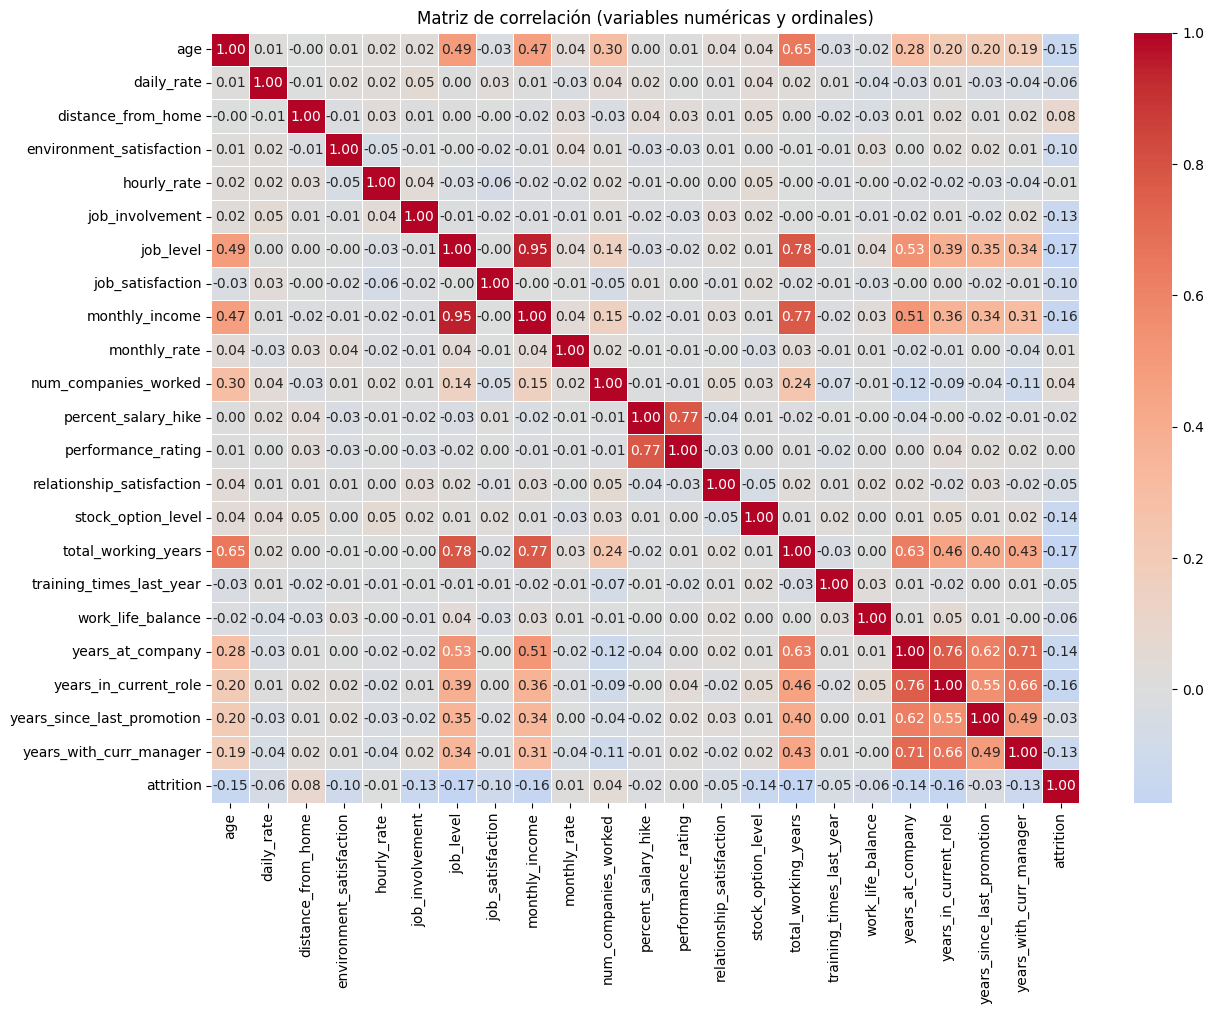

In [6]:
# cálculo de la matriz de correlación
corr_matrix = df_corr.corr(method='pearson')

# ver valores numéricos
corr_matrix.round(2)

# visualización de la matriz de correlación
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,          # <-- esto muestra los números
    fmt=".2f",           # <-- 2 decimales
    linewidths=0.5
)

plt.title('Matriz de correlación (variables numéricas y ordinales)')
plt.show()

La matriz de correlación se ha calculado únicamente con variables numéricas y ordinales, excluyendo identificadores y variables categóricas, con el fin de garantizar una interpretación estadísticamente coherente de los resultados.

### OBSERVACIONES

🔹 A. Bloques fuertes (esperados y sanos)

Estos NO se discuten, se reconocen como estructura del negocio:

Salario / nivel / experiencia

job_level ↔ monthly_income → 0.95

total_working_years ↔ job_level → 0.78

total_working_years ↔ monthly_income → 0.77

📌 Esto valida que:

el dataset es coherente

las variables están bien definidas


🔹 B. Antigüedad interna (otro bloque lógico)

Correlaciones altas entre:

years_at_company

years_in_current_role

years_with_curr_manager

years_since_last_promotion

👉 No es “ruido”, es estructura temporal.


🔎 Ahora lo importante: Attrition

Vamos a la última fila/columna, que es la que interesa.

📊 Correlaciones más relevantes con attrition

Variable	            Correlación	        Lectura
job_level	                -0.17	        Menor nivel → más rotación
monthly_income	            -0.16	        Menor salario → más rotación
total_working_years	        -0.17	        Menos experiencia → más rotación
years_at_company	        -0.14	        Menor antigüedad → más rotación
years_in_current_role   	-0.16	        Menos estabilidad → más rotación
years_with_curr_manager     -0.13	        Menor continuidad → más rotación

📌 Todas son:

negativas

débiles–moderadas

coherentes entre sí

👉 Esto es exactamente lo que esperamos en HR.


🔹 Variables con baja o nula correlación (y está bien)

job_satisfaction ≈ -0.10

work_life_balance ≈ -0.06

environment_satisfaction ≈ -0.10

⚠️ Importante:

Que la correlación sea baja NO invalida lo que visteis en los gráficos.

###  RESUMEN Tabla de Correlaciones

La matriz de correlación muestra que la rotación de empleados presenta correlaciones negativas débiles con variables relacionadas con la experiencia, el nivel del puesto y la antigüedad en la empresa. Esto sugiere que los empleados con menor estabilidad y menor nivel jerárquico tienden a presentar mayores niveles de rotación.

Las variables de satisfacción muestran correlaciones lineales bajas con la rotación, lo que indica que su relación con Attrition podría no ser estrictamente lineal y debe analizarse mediante otros enfoques exploratorios.

En conjunto, estos resultados refuerzan los patrones identificados en el análisis exploratorio previo y ponen de manifiesto que la rotación de empleados es un fenómeno multifactorial que no puede explicarse mediante una única variable.

## TABLA DE CONTINGENCIA PARA VARIABLES CATEGÓRICAS 

Diferencias en la distribución de Attrition entre categorías

Para analizar Attrition, la regla es:

🔑 La interpretación siempre se hace con proporciones, no con conteos (ver tamaños, detectar categorías pequeñas y justificar cautela)

### BUSSINESS TRAVEL

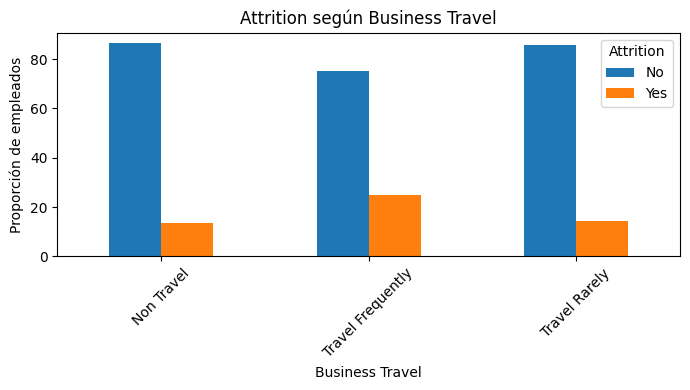

In [7]:
prop_bt = pd.crosstab(
    df_abc['business_travel'],
    df_abc['attrition'],
    normalize='index'
) * 100

prop_bt.plot(kind='bar', figsize=(7,4))

plt.title('Attrition según Business Travel')
plt.xlabel('Business Travel')
plt.ylabel('Proporción de empleados')
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

### OBSERVACIONES Business travel

GRÁFICO CÓMUN: Incluso en conteos se intuye algo importante:

Non Travel → pocos “Yes”.

Travel Frequently → muchos “Yes” en proporción a su tamaño.

Travel Rarely → muchos “Yes” porque es el grupo más grande.

👉 Esto coincide exactamente con la tabla de contingencia que vimos antes.


GRÁFICO ACTUAL: Lectura clara del patrón: Lo que se observa:

Non Travel → Attrition bajo (≈ 13–14%).

Travel Rarely → Attrition similar, ligeramente superior.

Travel Frequently → Attrition claramente más alto (≈ 25%).

👉 La diferencia es visual y cuantitativamente clara.


Esto es un resultado fuerte, especialmente porque: no depende de outliers, no depende de una única categoría pequeña y es coherente con OverTime y WorkLifeBalance.

Se observan diferencias claras en la proporción de empleados que presentan Attrition según la frecuencia de viajes laborales. Los empleados que viajan con mayor frecuencia muestran una tasa de rotación significativamente superior en comparación con aquellos que no viajan o viajan rara vez.

Este patrón sugiere que una mayor exigencia de movilidad podría estar asociada a un mayor riesgo de abandono, en línea con otros factores relacionados con la carga de trabajo analizados previamente.

No obstante, este análisis es exploratorio y no permite establecer relaciones causales, por lo que los resultados deben interpretarse como asociaciones.

### MARITAL STATUS

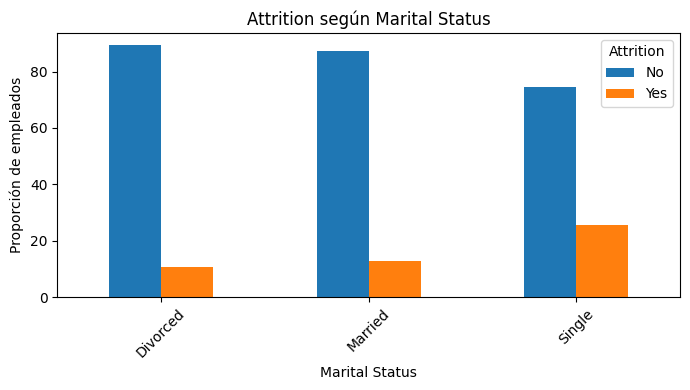

In [8]:
prop_ms = pd.crosstab(
    df_abc['marital_status'],
    df_abc['attrition'],
    normalize='index'
) * 100

prop_ms.plot(kind='bar', figsize=(7,4))

plt.title('Attrition según Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Proporción de empleados')
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

### OBSERVACIONES Marital Status

GRÁFICO COMÚN: muestra conteos absolutos:

Hay más Married porque hay más empleados casados.

Single parece tener muchos “Yes”, pero también es un grupo grande.

📌 Con conteos no podemos comparar riesgo de Attrition entre estados civiles.

👉 Igual que antes: sirve para tamaños, no para conclusiones.


GRÁFICO ACTUAL: Lectura del patrón: Lo que se observa claramente:

Single → mayor proporción de Attrition (≈ 25%).

Married → Attrition más bajo (≈ 13%).

Divorced → Attrition similar o ligeramente inferior a Married (≈ 11%).

👉 Las diferencias son claras y consistentes.


Se observan diferencias en la proporción de empleados que presentan Attrition según el estado civil. El grupo de empleados solteros muestra una tasa de rotación superior en comparación con los empleados casados y divorciados.

Este resultado sugiere que el estado civil podría estar asociado a distintos niveles de estabilidad laboral, si bien esta relación debe interpretarse con cautela y en combinación con otros factores personales y profesionales.

Dado el carácter exploratorio del análisis, no es posible establecer relaciones causales a partir de estos resultados.

### DEPARTMENT

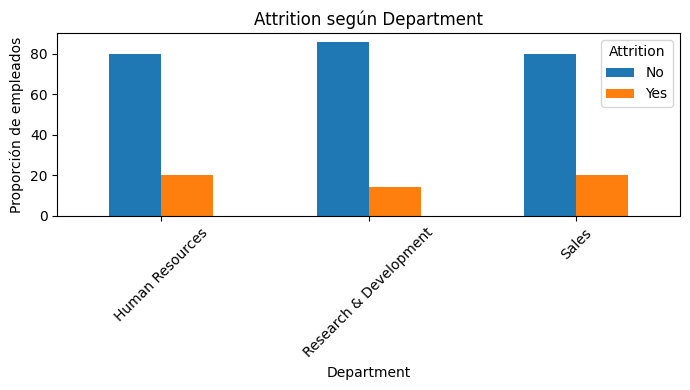

In [9]:
prop_dep = pd.crosstab(
    df_abc['department'],
    df_abc['attrition'],
    normalize='index'
) * 100

prop_dep.plot(kind='bar', figsize=(7,4))

plt.title('Attrition según Department')
plt.xlabel('Department')
plt.ylabel('Proporción de empleados')
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

### OBSERVACIONES Department

GRÁFICO COMÚN: El gráfico es de conteos absolutos:

Research & Development domina porque es el departamento más grande.

Human Resources parece pequeño, pero también lo es en tamaño real.

Sales queda en medio.

📌 Con este gráfico no podemos comparar riesgo de Attrition, solo tamaños.

👉 No está mal, pero no es el que interpretamos.


GRÁFICO ACTUAL: Lectura de Patrón:

Sí hay diferencias: Research & Development → menor Attrition (~14–15%), Sales → mayor Attrition (~20%) y Human Resources → similar o ligeramente superior (~20%)

Son moderadas, no extremas. No hay un departamento con 40–50% de Attrition. Las diferencias son de ~5–7 puntos porcentuales.

Cautela: Sales vs R&D → comparación fiable (ambos con tamaños grandes) y HR vs resto → comparación no tan fiable (grupo pequeño).

No son compables del todo los tamaños: R&D ≫ Sales ≫ HR. Por eso: Sales → patrón más robusto y HR → patrón frágil (pocos casos)

👉 Patrón visible, no ruido puro.


Se observan diferencias moderadas en la proporción de empleados que presentan Attrition entre los distintos departamentos. Los departamentos de Sales y Human Resources muestran tasas de rotación superiores en comparación con Research & Development, que presenta una mayor estabilidad.

No obstante, el departamento de Human Resources cuenta con un número reducido de empleados en comparación con el resto de departamentos, por lo que su mayor proporción de Attrition debe interpretarse con cautela.

### JOB ROLE

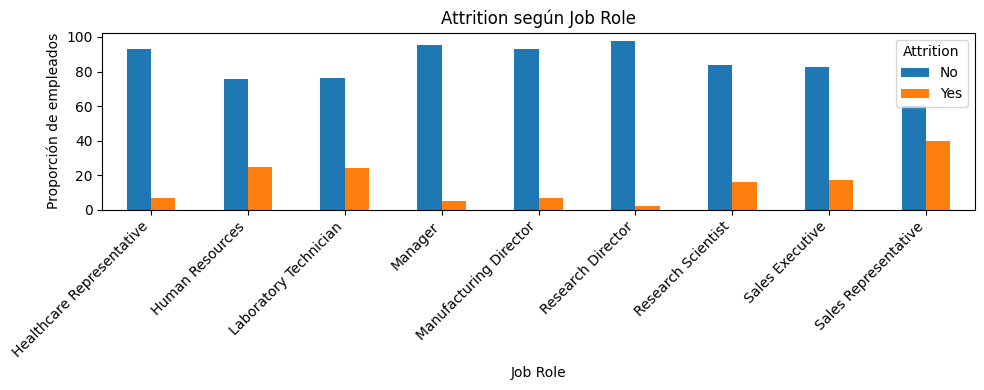

In [10]:
prop_jr = pd.crosstab(
    df_abc['job_role'],
    df_abc['attrition'],
    normalize='index'
) * 100

prop_jr.plot(kind='bar', figsize=(10,4))

plt.title('Attrition según Job Role')
plt.xlabel('Job Role')
plt.ylabel('Proporción de empleados')
plt.legend(title='Attrition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### OBSERVACIONES Job Role

GRÁFICO COMUN: muestra conteos absolutos: Research Scientist y Sales Executive dominan porque son roles muy numerosos. Sales Representative parece “pequeño”, pero eso no dice nada del riesgo de Attrition. Research Director casi no aparece (muy pocos casos)

📌 Con conteos no podemos comparar riesgo de rotación entre roles.

👉 Igual que antes: sirve para tamaños, no para conclusiones.


GRÁFICO ACTUAL: Lectura del patrón:

🔥 Roles con mayor proporción de Attrition

Sales Representative → claramente el más alto (~40%)

Laboratory Technician → elevado (~24%)

Human Resources → relativamente alto (~24%)

👉 Son roles más operativos / comerciales.


🔹 Roles con Attrition intermedio

Sales Executive

Research Scientist

👉 En torno al 15–18%.


🔹 Roles con Attrition bajo

Manager

Manufacturing Director

Research Director

Healthcare Representative

👉 Roles con: mayor seniority, más estabilidad y mayor responsabilidad.

Aquí es obligatorio añadir contexto de tamaños: Algunos roles con Attrition muy alto (Sales Representative) → tamaño moderado, patrón relevante.

Otros con Attrition muy bajo (Research Director) → tamaño limitado, cautela.

👉 El patrón general es consistente, pero no todos los roles pesan igual.


Se observan diferencias relevantes en la proporción de empleados que presentan Attrition según el rol desempeñado. Algunos roles operativos y comerciales, como Sales Representative y Laboratory Technician, muestran tasas de rotación claramente superiores a la media, mientras que roles de mayor responsabilidad o carácter directivo presentan niveles de Attrition más bajos.

Estas diferencias sugieren que el tipo de rol y las condiciones asociadas al puesto podrían estar relacionadas con distintos niveles de estabilidad laboral. No obstante, los resultados deben interpretarse con cautela, especialmente en aquellos roles con un número reducido de empleados.

## RESUMEN de variables categóricas (principales)

El análisis de las variables categóricas muestra que la rotación de empleados no es homogénea entre los distintos grupos analizados. Variables relacionadas con las condiciones del puesto y el contexto laboral, como la frecuencia de viajes, el rol desempeñado o el estado civil, presentan diferencias más marcadas en la proporción de Attrition.

En contraste, otras variables categóricas analizadas posteriormente, como el género o el nivel educativo, muestran un impacto menos significativo, lo que refuerza la naturaleza multifactorial del fenómeno de la rotación.

### Variables categóricas con menor impacto

El análisis de variables como género, nivel educativo y campo de estudios no muestra diferencias significativas en la proporción de Attrition. Estos resultados sugieren que dichas variables, de forma aislada, no parecen desempeñar un papel determinante en la rotación de empleados dentro del conjunto de datos analizado.

### GÉNERO

In [11]:
pd.crosstab(
    df_abc['gender'],
    df_abc['attrition'],
    normalize='index'
) * 100

attrition,No,Yes
gender,,
Female,85.229202,14.770798
Male,82.937853,17.062147


El análisis por género muestra diferencias leves en la proporción de Attrition, con una tasa ligeramente superior en hombres que en mujeres. No obstante, la magnitud de esta diferencia es reducida, lo que sugiere que el género no parece ser un factor determinante en la rotación de empleados dentro de este conjunto de datos.

### EDUCATION

In [12]:
pd.crosstab(
    df_abc['education'],
    df_abc['attrition'],
    normalize='index'
) * 100

attrition,No,Yes
education,,
Bachelor,82.752613,17.247387
Below College,81.286550,18.713450
College,84.452297,15.547703
Doctor,89.583333,10.416667
Master,85.427136,14.572864


El análisis del nivel educativo muestra una ligera tendencia a una menor proporción de Attrition en los niveles educativos más altos. No obstante, las diferencias observadas son moderadas y no permiten considerar el nivel educativo como un factor determinante de la rotación de empleados. Además, algunas categorías, como Doctor, presentan un tamaño muestral reducido, por lo que los resultados deben interpretarse con cautela.

### EDUCATION FIELD

In [13]:
pd.crosstab(
    df_abc['education_field'],
    df_abc['attrition'],
    normalize='index'
) * 100

attrition,No,Yes
education_field,,
Human Resources,75.000000,25.000000
Life Sciences,85.051546,14.948454
Marketing,77.631579,22.368421
Medical,86.191537,13.808463
Other,87.591241,12.408759
Technical Degree,75.384615,24.615385


El análisis del campo de estudios muestra diferencias moderadas en la proporción de Attrition entre las distintas categorías. Algunos campos, como Human Resources, Marketing y Technical Degree, presentan tasas de rotación superiores, mientras que áreas como Medical y Life Sciences muestran una mayor estabilidad.

No obstante, estas diferencias deben interpretarse con cautela debido a la heterogeneidad en el tamaño de las categorías, por lo que el campo de estudios no puede considerarse un factor determinante de la rotación de empleados de forma aislada.

### Resumen final del Análisis Exploratorio de Datos

El análisis exploratorio realizado sobre el conjunto de datos ha permitido identificar patrones relevantes asociados a la rotación de empleados (Attrition), confirmando que se trata de un fenómeno complejo y multifactorial.

El estudio de las variables numéricas y ordinales, apoyado por la matriz de correlación, muestra que la rotación presenta correlaciones negativas débiles con variables relacionadas con la experiencia, el nivel del puesto y la antigüedad en la empresa, como el nivel jerárquico, el salario mensual y los años de permanencia. Estas relaciones sugieren que los empleados con menor estabilidad y menor nivel profesional tienden a mostrar mayores niveles de rotación, si bien ninguna variable por sí sola explica el fenómeno.

El análisis de las variables categóricas principales revela diferencias más marcadas en la proporción de Attrition según factores vinculados a las condiciones del puesto y al contexto laboral. Variables como la frecuencia de viajes, la realización de horas extra, el rol desempeñado y el estado civil muestran asociaciones claras con distintos niveles de rotación, destacando una mayor tasa de Attrition en perfiles con mayores exigencias operativas o comerciales.

Por el contrario, otras variables categóricas como el género, el nivel educativo y el campo de estudios presentan un impacto más limitado en la rotación, con diferencias moderadas o poco consistentes entre categorías, lo que refuerza la idea de que estos factores no actúan como determinantes principales de manera aislada.

En conjunto, los resultados del EDA ponen de manifiesto que la rotación de empleados responde a la interacción de múltiples factores personales, profesionales y organizativos. Este análisis proporciona una base sólida para futuras fases del proyecto, como la transformación de los datos, la visualización avanzada o la aplicación de modelos analíticos orientados a la predicción o segmentación del riesgo de Attrition.

# FEEDBACK A LA EMPRESA

🎯 Objetivo del feedback

Reducir la rotación de empleados actuando sobre factores organizativos y del puesto que muestran mayor asociación con Attrition.

1️⃣ Mensaje clave inicial (para directivos)

La rotación de empleados no responde a un único factor, sino a la combinación de condiciones del puesto, estabilidad profesional y contexto personal. Los datos sugieren que las mayores oportunidades de intervención se encuentran en el diseño del trabajo y en la gestión de la carga operativa.

Este framing es importante: no culpabiliza a personas, sino a procesos.

2️⃣ Principales hallazgos accionables (qué haría una empresa con esto)

🔹 A. Carga operativa y movilidad

Qué muestran los datos:

Mayor Attrition en:

empleados que viajan con frecuencia

empleados que realizan horas extra

Relación clara con menor WorkLifeBalance

Sugerencias de mejora:

Revisar políticas de viajes:

rotación de equipos

reducción de viajes innecesarios

compensaciones claras (flexibilidad, días extra)

Monitorizar de forma activa las horas extra:

detectar equipos con sobrecarga recurrente

intervenir antes de que se normalice

📌 Impacto esperado:
Reducción de rotación en perfiles operativos y comerciales.


🔹 B. Roles con mayor riesgo de rotación

Qué muestran los datos:

Mayor Attrition en:

Sales Representative

Laboratory Technician

algunos roles comerciales y operativos

Sugerencias de mejora:

Revisar:

expectativas del rol vs. realidad del puesto

procesos de onboarding

planes de desarrollo temprano

Implementar:

check-ins periódicos en los primeros meses

mentoring para roles de alta rotación

📌 Impacto esperado:
Mejor retención en posiciones clave y reducción de costes de reemplazo.


🔹 C. Estabilidad profesional y desarrollo

Qué muestran los datos:

Menor Attrition en empleados con:

mayor antigüedad

mayor nivel jerárquico

salarios más altos

Mayor Attrition en perfiles más junior

Sugerencias de mejora:

Definir rutas de crecimiento claras desde etapas tempranas

Comunicar expectativas de promoción de forma transparente

Reforzar formación y desarrollo en los primeros años

📌 Impacto esperado:
Mayor compromiso y menor rotación temprana.


3️⃣ Factores con menor impacto (qué NO priorizar)

Qué muestran los datos:

Género, nivel educativo y campo de estudios presentan diferencias limitadas o inconsistentes.

Sugerencia:

No centrar estrategias de retención en estos factores de forma aislada.

Usarlos solo como contexto, no como criterio de decisión.

📌 Mensaje importante:
Las políticas de retención deben centrarse en cómo se trabaja, no en quién es la persona.


4️⃣ Recomendaciones estratégicas (nivel más alto)

🔹 A. Enfoque preventivo

Crear indicadores tempranos de riesgo:

horas extra sostenidas

alta frecuencia de viajes

poco tiempo en el rol sin progresión

🔹 B. Segmentación del riesgo

No aplicar políticas generales

Diseñar acciones específicas para:

roles de alta rotación

empleados en los primeros años


5️⃣ Limitaciones del análisis (transparencia)

Este análisis es exploratorio y no permite establecer relaciones causales. Los resultados deben interpretarse como asociaciones que orientan posibles líneas de actuación, siendo recomendable complementarlos con análisis adicionales y datos cualitativos.


6️⃣ Cierre presentación

Los datos sugieren que la rotación no es un problema individual, sino un reflejo de cómo están diseñados ciertos roles y condiciones de trabajo. Actuar sobre estos factores puede tener un impacto significativo en la retención del talento.

Como líneas futuras de análisis, se propone profundizar en la interacción entre variables, la segmentación de perfiles de riesgo y la construcción de modelos predictivos que permitan anticipar la rotación y diseñar estrategias de retención más focalizadas.